# Analyse exploratoire des données marketing bancaires
Ce notebook présente une analyse exploratoire du jeu de données bancaire afin d’identifier les caractéristiques associées à la souscription d’un dépôt à terme.
L’objectif est de mieux comprendre les profils clients et les facteurs influençant la décision de souscription.

## Contexte
La banque a lancé une campagne de télémarketing afin de proposer un dépôt à terme à ses clients.
La variable cible `deposit` indique si le client a accepté l’offre (`yes`) ou non (`no`).
L’analyse exploratoire vise à :
- décrire la structure du jeu de données ;
- identifier les variables les plus informatives ;
- observer les tendances entre les variables explicatives et la cible ;
- préparer le prétraitement en vue d’une éventuelle modélisation.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [18]:
df = pd.read_csv("../Data/Raw/bank_data.csv")
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [19]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


In [20]:
print(f"Le dataset contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")


Le dataset contient 11162 lignes et 17 colonnes.


In [21]:
df.columns.tolist()


['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'deposit']

In [22]:
df.describe()


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [23]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [24]:
df.nunique().sort_values(ascending=False)


balance      3805
duration     1428
pdays         472
age            76
campaign       36
previous       34
day            31
month          12
job            12
poutcome        4
education       4
marital         3
contact         3
loan            2
housing         2
default         2
deposit         2
dtype: int64

In [25]:
print(f"Nombre de doublons : {df.duplicated().sum()}")


Nombre de doublons : 0


In [26]:
target_counts = df["deposit"].value_counts()
target_percent = df["deposit"].value_counts(normalize=True) * 100
print("Répartition absolue :")
print(target_counts)
print("\nRépartition en pourcentage :")
print(target_percent.round(2))

Répartition absolue :
deposit
no     5873
yes    5289
Name: count, dtype: int64

Répartition en pourcentage :
deposit
no     52.62
yes    47.38
Name: proportion, dtype: float64


C:\Users\samto\AppData\Local\Temp\ipykernel_23828\2934581910.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="deposit", palette="Set2")


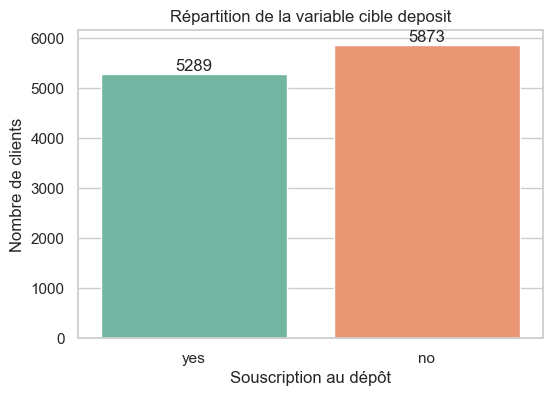

In [27]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="deposit", palette="Set2")
plt.title("Répartition de la variable cible deposit")
plt.xlabel("Souscription au dépôt")
plt.ylabel("Nombre de clients")
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom"
    )
plt.show()

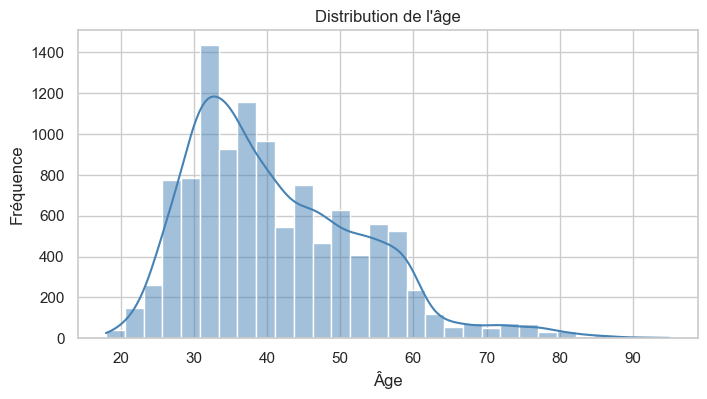

In [28]:
plt.figure(figsize=(8, 4))
sns.histplot(df["age"], bins=30, kde=True, color="steelblue")
plt.title("Distribution de l'âge")
plt.xlabel("Âge")
plt.ylabel("Fréquence")
plt.show()

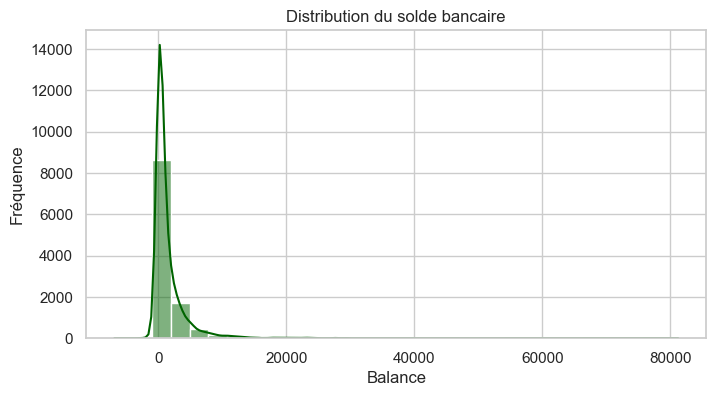

In [29]:
plt.figure(figsize=(8, 4))
sns.histplot(df["balance"], bins=30, kde=True, color="darkgreen")
plt.title("Distribution du solde bancaire")
plt.xlabel("Balance")
plt.ylabel("Fréquence")
plt.show()


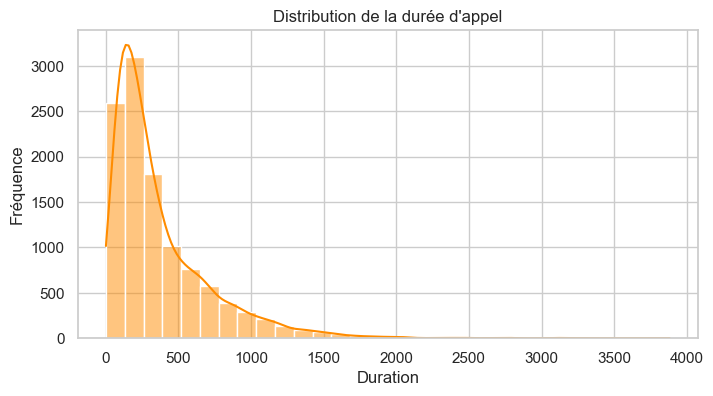

In [30]:
plt.figure(figsize=(8, 4))
sns.histplot(df["duration"], bins=30, kde=True, color="darkorange")
plt.title("Distribution de la durée d'appel")
plt.xlabel("Duration")
plt.ylabel("Fréquence")
plt.show()

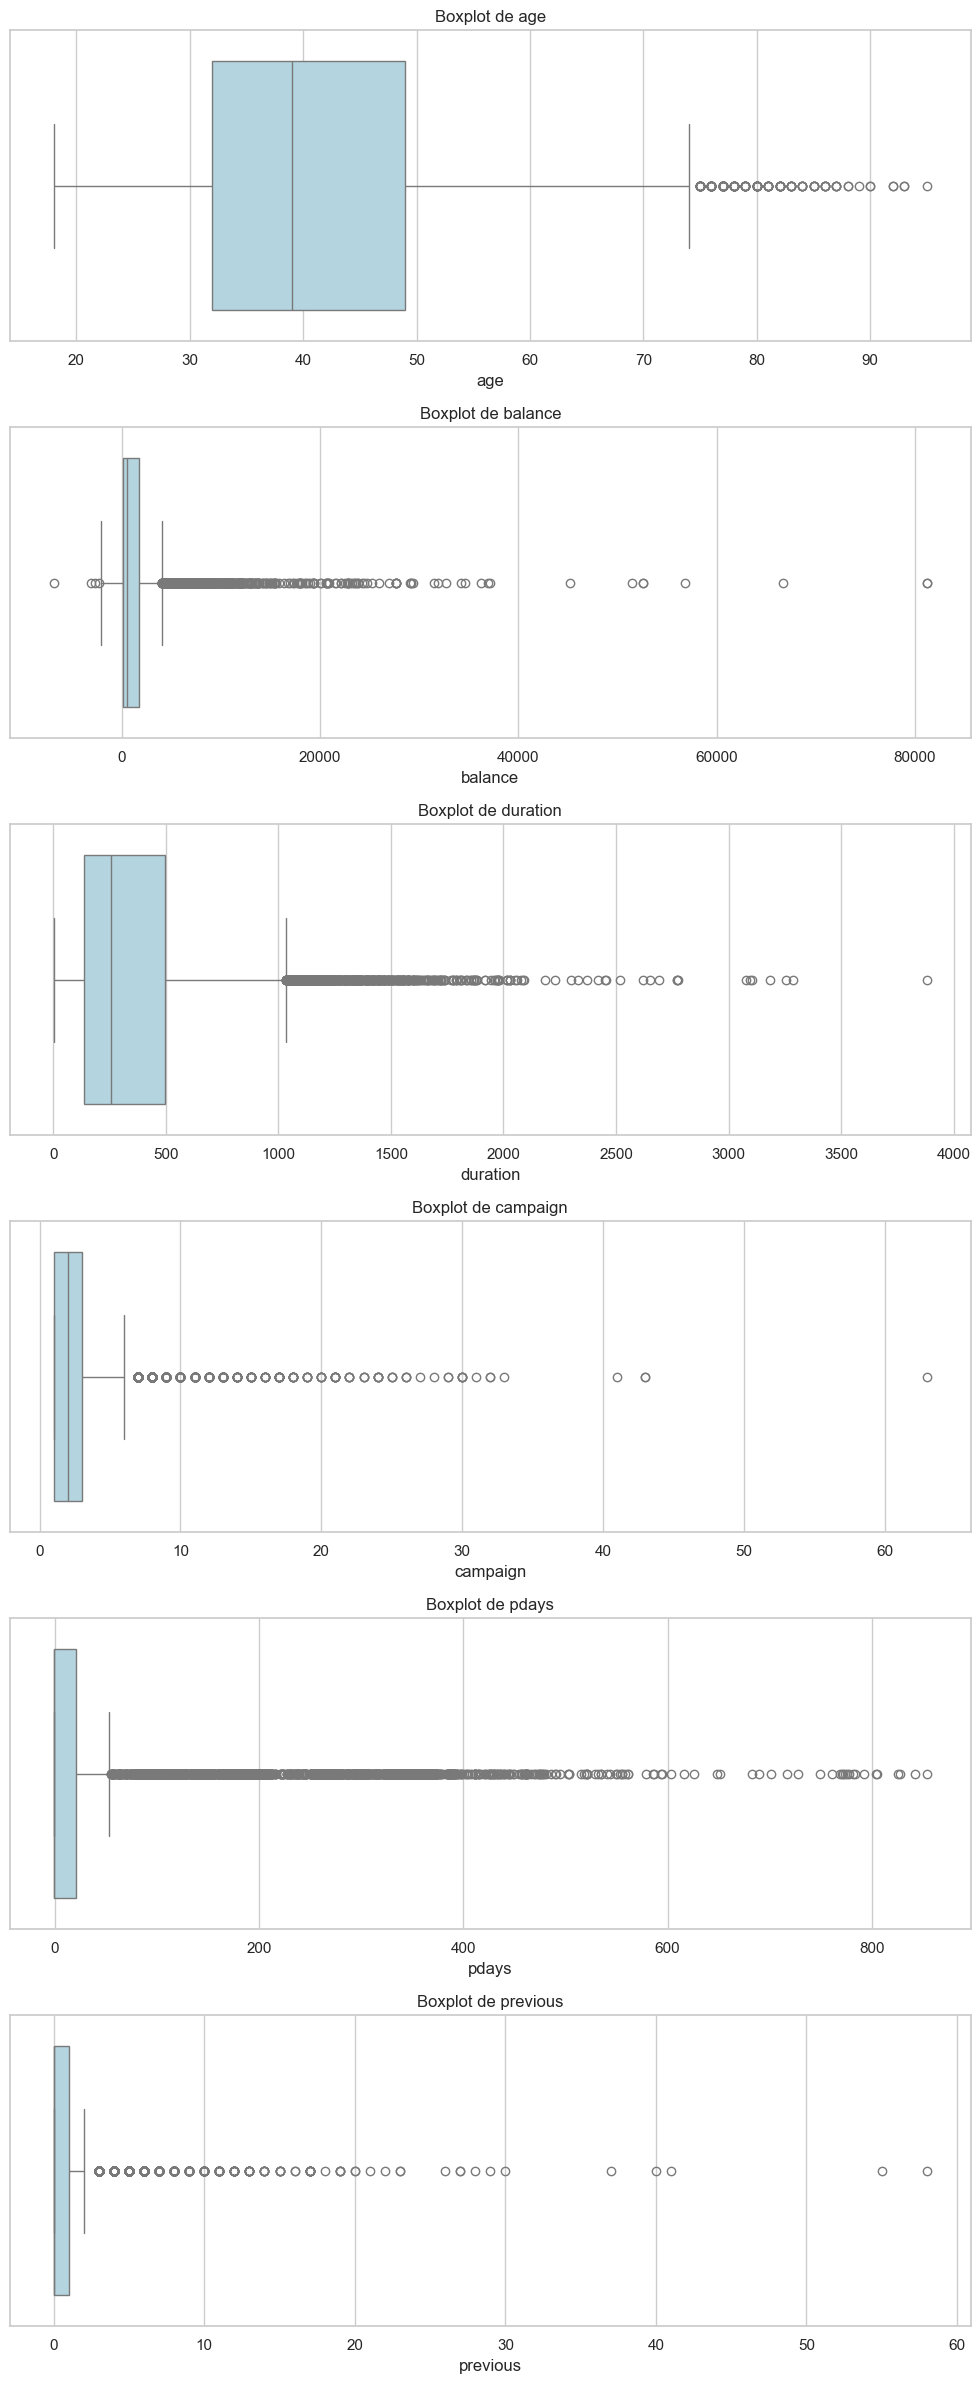

In [31]:
numeric_cols = ["age", "balance", "duration", "campaign", "pdays", "previous"]
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(10, 24))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x=col, ax=ax, color="lightblue")
    ax.set_title(f"Boxplot de {col}")
plt.tight_layout()
plt.show()

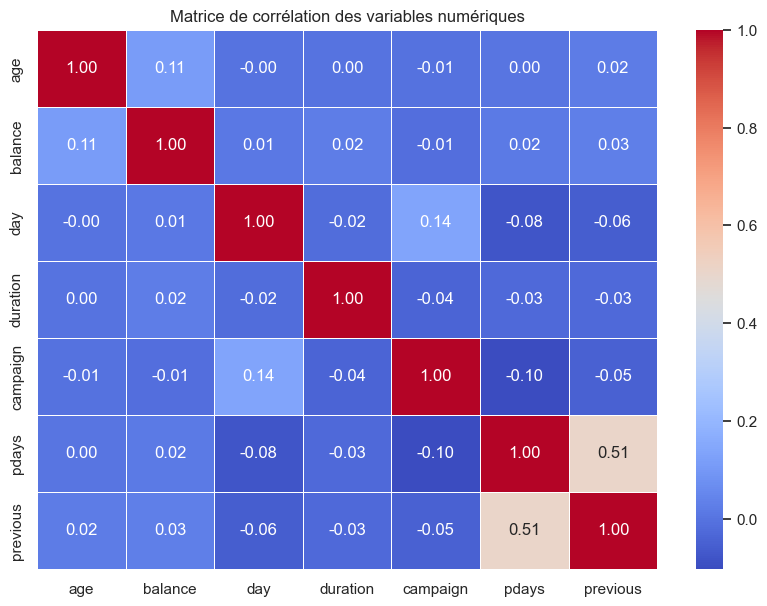

In [32]:
plt.figure(figsize=(10, 7))
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation des variables numériques")
plt.show()

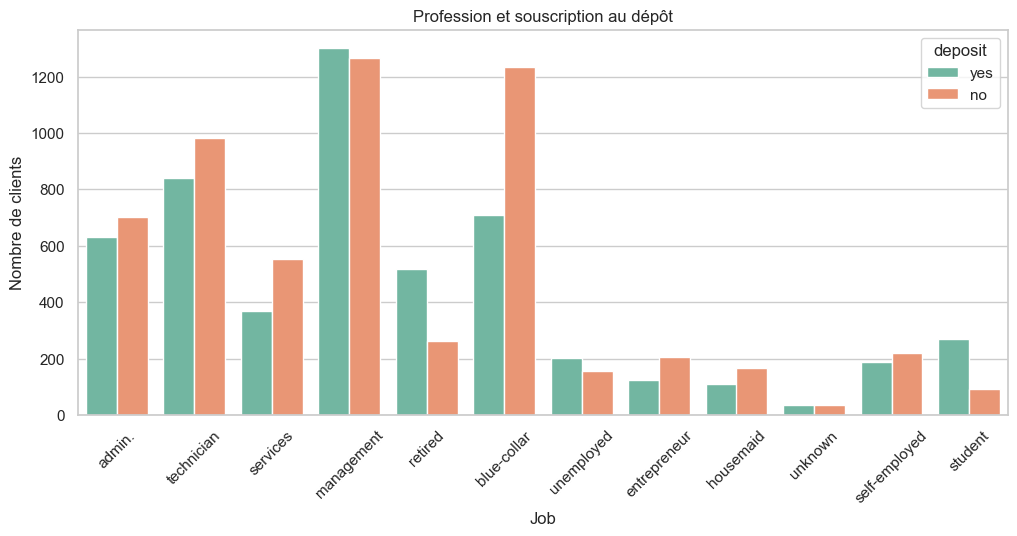

In [33]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="job", hue="deposit", palette="Set2")
plt.title("Profession et souscription au dépôt")
plt.xlabel("Job")
plt.ylabel("Nombre de clients")
plt.xticks(rotation=45)
plt.show()

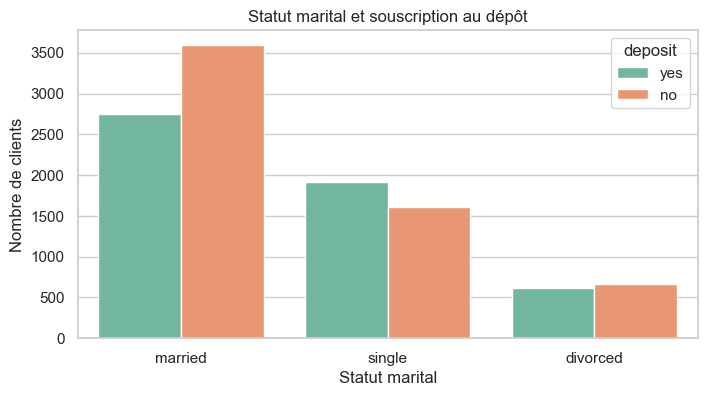

In [34]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="marital", hue="deposit", palette="Set2")
plt.title("Statut marital et souscription au dépôt")
plt.xlabel("Statut marital")
plt.ylabel("Nombre de clients")
plt.show()


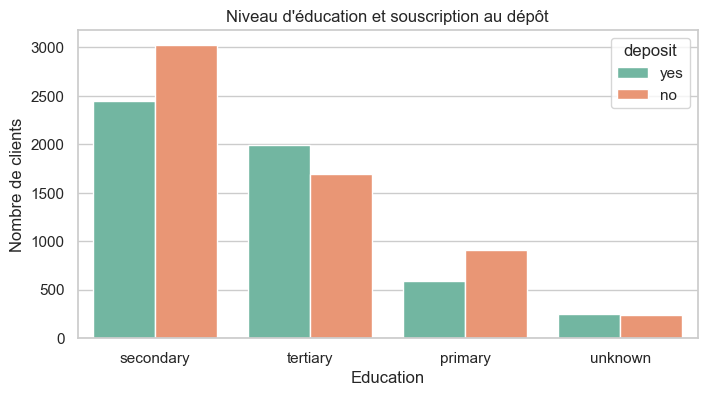

In [35]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="education", hue="deposit", palette="Set2")
plt.title("Niveau d'éducation et souscription au dépôt")
plt.xlabel("Education")
plt.ylabel("Nombre de clients")
plt.show()

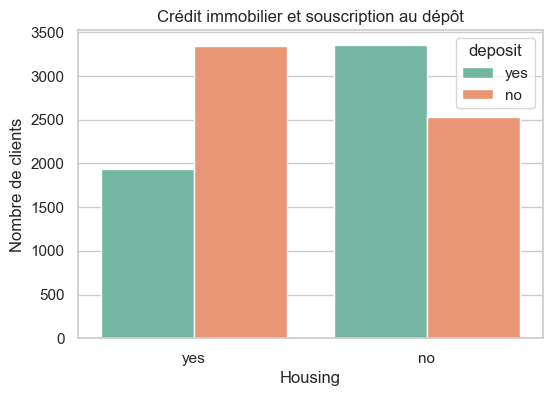

In [36]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="housing", hue="deposit", palette="Set2")
plt.title("Crédit immobilier et souscription au dépôt")
plt.xlabel("Housing")
plt.ylabel("Nombre de clients")
plt.show()

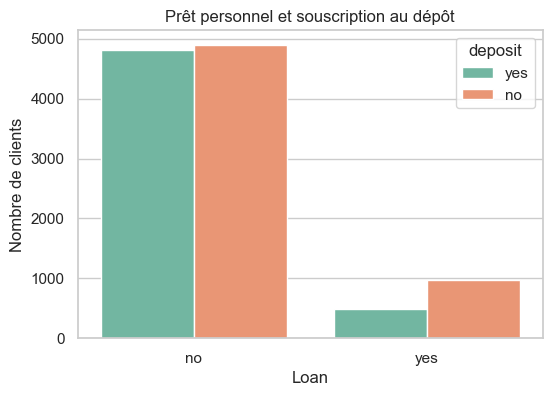

In [37]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="loan", hue="deposit", palette="Set2")
plt.title("Prêt personnel et souscription au dépôt")
plt.xlabel("Loan")
plt.ylabel("Nombre de clients")
plt.show()

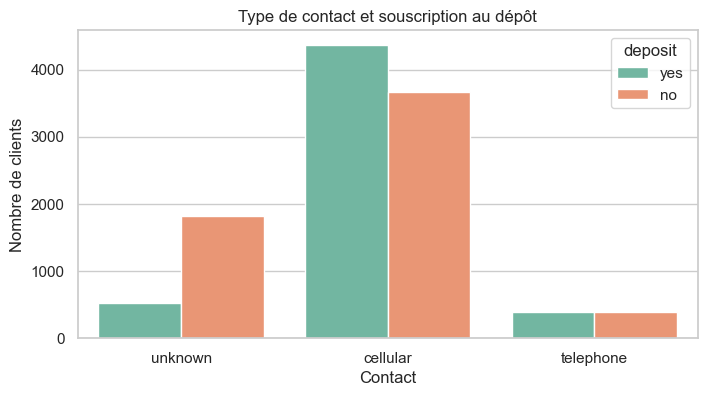

In [38]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="contact", hue="deposit", palette="Set2")
plt.title("Type de contact et souscription au dépôt")
plt.xlabel("Contact")
plt.ylabel("Nombre de clients")
plt.show()


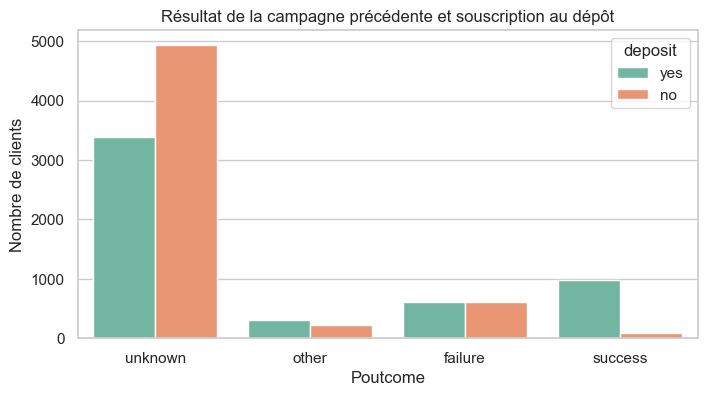

In [39]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="poutcome", hue="deposit", palette="Set2")
plt.title("Résultat de la campagne précédente et souscription au dépôt")
plt.xlabel("Poutcome")
plt.ylabel("Nombre de clients")
plt.show()

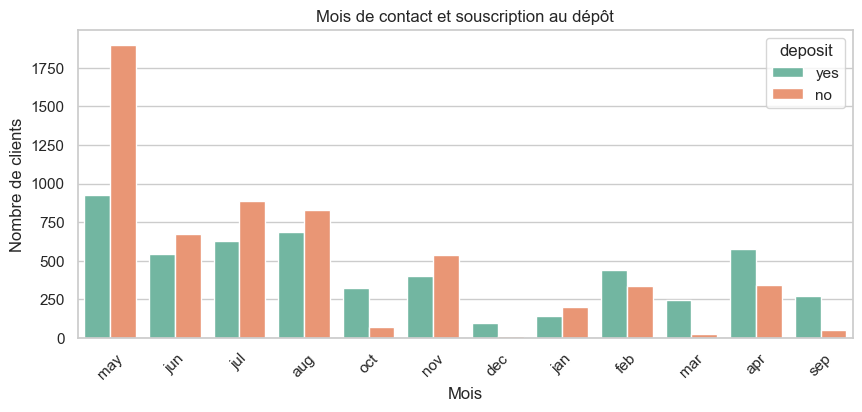

In [40]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="month", hue="deposit", palette="Set2")
plt.title("Mois de contact et souscription au dépôt")
plt.xlabel("Mois")
plt.ylabel("Nombre de clients")
plt.xticks(rotation=45)
plt.show()